In [ ]:
#https://www.youtube.com/watch?v=8PzQSgw0SpM&list=PLIuxvt_7DCfncIqV4EE9kCKY_Lh59M_9e&index=14&t=4s

In [32]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
data = yf.download(tickers='QQQ', period='1y', interval='1h')
data

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
2021-10-15 09:30:00-04:00,367.880005,368.160004,366.820007,366.936890,366.936890,9299421
2021-10-15 10:30:00-04:00,366.940002,368.630005,366.940002,368.260010,368.260010,4518931
2021-10-15 11:30:00-04:00,368.250000,368.409912,367.125000,367.799988,367.799988,6898740
2021-10-15 12:30:00-04:00,367.799988,368.140015,367.579987,367.799988,367.799988,3794769
2021-10-15 13:30:00-04:00,367.809998,368.528015,367.804993,368.399994,368.399994,2355215
...,...,...,...,...,...,...
2022-10-14 12:30:00-04:00,262.769989,263.515015,261.829987,262.549988,262.549988,6513897
2022-10-14 13:30:00-04:00,262.540009,263.250000,261.260010,261.750000,261.750000,5179900
2022-10-14 14:30:00-04:00,261.720001,262.450012,261.010010,261.679993,261.679993,5896436
2022-10-14 15:30:00-04:00,261.690002,262.191193,260.140015,260.630005,260.630005,8922831


In [108]:
SMA20 = data.Close.rolling(20).mean()

std = data.Close.rolling(20).std()

In [109]:
def BollingerBands(data):
    data['UpperBand'] = SMA20 + std*2
    data['LowerBand'] = SMA20 - std*2
    
data.head(BollingerBands(data))    

,Open,High,Low,Close,Adj Close,Volume,UpperBand,LowerBand
2021-10-15 09:30:00-04:00,367.880005,368.160004,366.820007,366.936890,366.936890,9299421,NaN,NaN
2021-10-15 10:30:00-04:00,366.940002,368.630005,366.940002,368.260010,368.260010,4518931,NaN,NaN
2021-10-15 11:30:00-04:00,368.250000,368.409912,367.125000,367.799988,367.799988,6898740,NaN,NaN
2021-10-15 12:30:00-04:00,367.799988,368.140015,367.579987,367.799988,367.799988,3794769,NaN,NaN
2021-10-15 13:30:00-04:00,367.809998,368.528015,367.804993,368.399994,368.399994,2355215,NaN,NaN
...,...,...,...,...,...,...,...,...
2022-10-14 12:30:00-04:00,262.769989,263.515015,261.829987,262.549988,262.549988,6513897,269.512785,258.988316
2022-10-14 13:30:00-04:00,262.540009,263.250000,261.260010,261.750000,261.750000,5179900,269.528277,258.935935
2022-10-14 14:30:00-04:00,261.720001,262.450012,261.010010,261.679993,261.679993,5896436,269.559186,258.784024
2022-10-14 15:30:00-04:00,261.690002,262.191193,260.140015,260.630005,260.630005,8922831,269.641663,258.422997


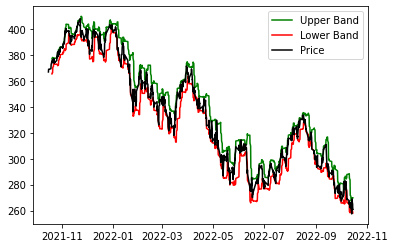

In [110]:
plt.plot(data.UpperBand, label='Upper Band', color='green')
plt.plot(data.LowerBand, label='Lower Band', color='red')
plt.plot(data.Close, label='Price', color='black')

plt.legend()
plt.show()

In [111]:
Buy, Sell = [], []

for i in range (2,len(data)):

    if data.Close.iloc[i] < data.LowerBand.iloc[i] and data.Close.iloc[i-1] > data.LowerBand.iloc[i-1]:
        Buy.append(i)
        
    if data.Close.iloc[i] > data.UpperBand.iloc[i]  and data.Close.iloc[i-1] < data.UpperBand.iloc[i-1]: 
        Sell.append(i)

In [112]:
Buy

[119,
 129,
 189,
 226,
 268,
 284,
 312,
 370,
 383,
 393,
 410,
 412,
 437,
 464,
 468,
 473,
 535,
 575,
 604,
 626,
 669,
 676,
 713,
 808,
 830,
 851,
 904,
 909,
 1003,
 1035,
 1038,
 1143,
 1152,
 1227,
 1236,
 1299,
 1425,
 1427,
 1481,
 1488,
 1518,
 1520,
 1544,
 1612,
 1614,
 1641,
 1719,
 1747]

In [113]:
Realbuys = [i+1 for i in Buy]
Realsells = [i+1 for i in Sell]

In [114]:
Buyprices = data.Open.iloc[Realbuys]
Sellprices = data.Open.iloc[Realsells]

In [115]:
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])
    
elif Buyprices.index[-1] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Sellprices.index[-1])    

In [116]:
profitsrel = []

for i in range(len(Sellprices)):
    profitsrel.append((Sellprices[i]-Buyprices[i])/Buyprices[i])
    
# aus irgendeinem Grund funktioniert hier in Zeile 2 len(Sellprices) aber len(Buyprices) nicht. Wie man aber bei allen anderen
# Strategien sieht, sollte das keinen Unterschied machen. Wieso macht es hier einen? Weil Sell-Befehl früher startet und später 
# aufhört als Buy-Befehl?

In [117]:
profit = sum(profitsrel)
print (profit)

# das heißt hiermit machen wir 180,77% minus

-1.8076503226846112
